In [1]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware

from models.llm import get_llm


In [ ]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

model = get_llm()

# 1️⃣ Create SQLite connection (file-based)
conn = sqlite3.connect("agent_memory.db", check_same_thread=False)

# 2️⃣ Create checkpointer
checkpointer = SqliteSaver(conn)

# 3️⃣ Create agent
agent = create_agent(
    model=model,
    checkpointer=checkpointer,
    middleware=[
        SummarizationMiddleware(
            model,
            trigger=("messages", 10),
            keep=("messages", 4),
        )
    ],
)

# 4️⃣ Config MUST keep same thread_id
config = {
    "configurable": {
        "thread_id": "test1"
    }
}


In [4]:
conn.close()


In [ ]:

model = get_llm()
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model,
        trigger=("messages",10),
        keep=("messages",4) 
    )],
)

config = {
    "configurable":{
        "thread_id": "test1"
    }
}

In [3]:
questions = [
    "Keep all these answers short and in one line",
    "Hi I am Hamza",
    "what is my name?",
    "what is python?",
    "what is compiled vs interpreted language?",
    "what is static vs dynamic language?",
]

for question in questions:
    response = agent.invoke({"messages":[
        ("human", question),
    ]},config)
    print(f"Messages: {response}")
    print(f"Count: {len(response['messages'])}")

    

Messages: {'messages': [HumanMessage(content='Keep all these answers short and in one line', additional_kwargs={}, response_metadata={}, id='e1fd42cc-095b-45e4-8cc6-566f41f43112'), AIMessage(content='<think>\nOkay, the user wants all answers short and in one line. Let me make sure I understand. They probably need concise responses without any extra details. Maybe they\'re looking for quick facts or bullet points. I should avoid explanations and just state the answer clearly. Let me check the previous example they gave. The assistant answered "The capital of France is Paris." That\'s direct. I need to follow that format. Also, the user mentioned keeping answers short, so I should trim any unnecessary words. Let me practice with a few examples. If they ask "What is the largest planet?" the answer would be "Jupiter." If they ask "Who wrote \'Hamlet\'?" the answer is "William Shakespeare." I need to make sure each response is a single line and as brief as possible. Alright, I think I got i

In [58]:
response = agent.invoke({"messages":[
    ("human", "Hi I am Hamza"),

]},config)
response

{'messages': [HumanMessage(content='Keep all these answers short and in one lineHi I am Hamza', additional_kwargs={}, response_metadata={}, id='f23e4479-8e1c-47d3-b36c-bd4b9fb96756'),
  AIMessage(content='<think>\nOkay, the user said, "Hi I am Hamza" and wants all answers short and in one line. Let me start by acknowledging his greeting. I should respond with a friendly greeting and offer help. Maybe something like, "Hi Hamza! How can I assist you today?" That\'s concise and opens the door for him to ask questions. I need to make sure I keep each response to one line and avoid any extra information unless necessary. Let me check if there\'s anything else he might need. Since he introduced himself, maybe he has a specific request, but since he didn\'t mention it, just a general offer to help should suffice. Alright, that should work.\n</think>\n\nHi Hamza! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 22

In [36]:
response = agent.invoke({"messages":[
    ("human", "what is my name?"),

]},config)
response["messages"][-1].content

'<think>\nOkay, the user just asked, "what is my name?" after introducing himself as Hamza. Let me check the conversation history.\n\nIn the previous message, the user said, "Hi I am Hamza," and I responded with a greeting. Now, they\'re asking for their name again. That\'s a bit confusing because they already provided it. Maybe they\'re testing if I remember, or perhaps there\'s a misunderstanding. \n\nI need to confirm if they\'re asking for their own name again. Since they introduced themselves as Hamza, I should acknowledge that. But wait, maybe they\'re referring to my name? No, the question is "what is my name?" which would be their own name. \n\nWait, maybe there\'s a technical issue where the system forgot the previous message. But in the history, it\'s there. So I should respond by confirming their name is Hamza. However, the user might be trying to see if I can recall the context correctly. \n\nI should make sure to answer clearly, restate their name, and offer further help. 

In [37]:
response = agent.invoke({"messages":[
    ("human", "what is python?"),

]},config)
response["messages"][-1].content

'<think>\nOkay, the user asked, "what is python?" Let me start by recalling the basics. Python is a programming language, but I need to explain it in a clear and concise way. The user\'s name is Hamza, and they might be new to programming or just curious.\n\nFirst, I should define Python. Mention that it\'s a high-level, interpreted language. Highlight its key features like readability, simplicity, and versatility. Maybe compare it to other languages to emphasize its ease of use. \n\nNext, talk about its applications. Python is used in web development, data science, machine learning, automation, etc. Listing some popular frameworks and libraries like Django, Flask, NumPy, Pandas, TensorFlow could be helpful. \n\nAlso, mention the community support and availability of resources. Beginners often appreciate knowing that there\'s a large community and plenty of tutorials. \n\nI should structure the answer in a way that\'s easy to follow. Start with a definition, then key features, applicat

In [38]:
response = agent.invoke({"messages":[
    ("human", "what is compiled vs interpreted language?"),

]},config)
response["messages"][-1].content

'<think>\nOkay, the user asked, "what is compiled vs interpreted language?" Let me start by recalling the basics. I need to explain the difference clearly, maybe with examples.\n\nFirst, compiled languages. They are translated into machine code before execution. The compiler takes the entire code and converts it into an executable file. Examples like C, C++, Rust come to mind. The user might be familiar with these from previous questions. I should mention that the code is run directly by the CPU after compilation.\n\nThen interpreted languages. These are executed line by line by an interpreter. Each line is translated into machine code as it runs. Python is a classic example here. The user knows Python from earlier, so using that as an example makes sense. Also, maybe mention JavaScript or Ruby as other examples.\n\nWait, but some languages can be both. Like Python can be compiled into bytecode, but it\'s still interpreted. Java is another case where it\'s compiled to bytecode and then

In [39]:
response = agent.invoke({"messages":[
    ("human", "what is static vs dynamic language?"),

]},config)
response["messages"][-1].content

'<think>\nOkay, Hamza asked about static vs dynamic languages. Let me start by recalling what I know. Static and dynamic typing are related to how variables are handled in a programming language.\n\nFirst, static typing means that variable types are checked at compile time. So, you have to declare the type of a variable when you create it. For example, in Java, you write `int x = 5;` where `int` is the type. If you try to assign a string to `x`, the compiler will throw an error. This helps catch errors early and can make the code more efficient because the compiler knows the types in advance.\n\nDynamic typing, on the other hand, checks types at runtime. You don\'t have to declare the type when you create a variable. In Python, you can just write `x = 5` and later `x = "hello"` without any issues. The interpreter handles the type changes on the fly. This makes the code more flexible and easier to write quickly, but it can lead to runtime errors if you accidentally assign the wrong type

In [40]:
user_input = input()
response = agent.invoke({"messages":[
    ("human", user_input),

]},config)
response["messages"][-1].content

'<think>\nOkay, the user asked, "how are you?" after a conversation about Python, compiled vs. interpreted languages, and static vs. dynamic typing. Let me think about how to respond.\n\nFirst, I need to acknowledge their question. Since I\'m an AI, I don\'t have feelings, but I should express that in a friendly way. Maybe start with a cheerful emoji to keep the tone positive.\n\nI should also make sure to invite them to ask more questions if they need help. The previous interactions were educational, so keeping the response helpful and open-ended is key. Let me check if there\'s anything else they might need. Maybe mention specific topics they\'ve asked about to show I remember the context. But keep it concise and not too repetitive.\n\nAlso, use a friendly closing like "😊" to maintain a warm tone. Avoid any technical jargon here since the question is about my well-being, not programming. Make sure the response is clear and approachable.\n</think>\n\nI\'m just a language model, so I d

In [41]:
response["messages"]

[HumanMessage(content='Hi I am Hamza', additional_kwargs={}, response_metadata={}, id='93412b98-b6f1-481b-a3b9-4ebeee02ed30'),
 AIMessage(content='<think>\nOkay, the user introduced himself as Hamza. I should respond in a friendly and welcoming manner. Let me make sure to acknowledge his name and offer assistance. Maybe ask how I can help him today. Keep it simple and open-ended.\n</think>\n\nHello, Hamza! Nice to meet you. How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 13, 'total_tokens': 85, 'completion_time': 0.117773465, 'completion_tokens_details': None, 'prompt_time': 0.000478253, 'prompt_tokens_details': None, 'queue_time': 0.015146395, 'total_time': 0.118251718}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019beb8c-cd86-7670-a72b-71eb0c4a538e-0', tool_calls=[]

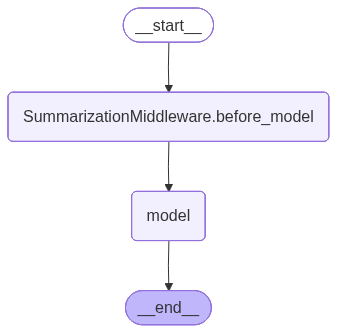

In [42]:
agent